In [42]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nifty_backtest_test_results.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5596 entries, 0 to 5595
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              5596 non-null   datetime64[ns]
 1   spot_open             5596 non-null   float64       
 2   spot_high             5596 non-null   float64       
 3   spot_low              5596 non-null   float64       
 4   spot_close            5596 non-null   float64       
 5   spot_volume           5596 non-null   int64         
 6   fut_open              5596 non-null   float64       
 7   fut_high              5596 non-null   float64       
 8   fut_low               5596 non-null   float64       
 9   fut_close             5596 non-null   float64       
 10  fut_volume            5596 non-null   int64         
 11  opt_open              5596 non-null   float64       
 12  opt_high              5596 non-null   float64       
 13  opt_low           

In [67]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgb_trade_filter.pkl")


['../models/xgb_trade_filter.pkl']

In [43]:
df["target"] = np.where(df["strategy_return"] > 0, 1, 0)


In [44]:
df_trades = df[df["trade_signal"] != 0].copy()

print("Total trades for ML:", len(df_trades))


Total trades for ML: 5353


In [45]:
base_features = [
    "ema_5",
    "ema_15",
    "spot_return",
    "rolling_volatility",
    "avg_iv",
    "iv_spread",
    "futures_basis",
    "delta_neutral_ratio",
    "gamma_exposure",
]


In [46]:
df_trades["regime_code"] = df_trades["regime"].astype(int)


In [47]:
df_trades["hour"] = df_trades["datetime"].dt.hour
df_trades["minute"] = df_trades["datetime"].dt.minute


In [48]:
df_trades["lag_return_1"] = df_trades["spot_return"].shift(1)
df_trades["lag_return_2"] = df_trades["spot_return"].shift(2)


In [49]:
df_trades["ema_gap"] = df_trades["ema_5"] - df_trades["ema_15"]


In [50]:
features = (
    base_features
    + ["regime_code", "hour", "minute"]
    + ["lag_return_1", "lag_return_2"]
    + ["ema_gap"]
)

df_trades = df_trades.dropna()

X = df_trades[features]
y = df_trades["target"]


In [51]:
split_idx = int(len(X) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [52]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [53]:
from sklearn.metrics import classification_report

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))


              precision    recall  f1-score   support

           0       0.97      0.98      0.97       927
           1       0.97      0.96      0.96       679

    accuracy                           0.97      1606
   macro avg       0.97      0.97      0.97      1606
weighted avg       0.97      0.97      0.97      1606



In [54]:
SEQ_LEN = 10

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X.iloc[i-seq_len:i].values)
        y_seq.append(y.iloc[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X, y, SEQ_LEN)


In [55]:
split_idx = int(len(X_seq) * 0.7)

X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10


2026-01-17 14:03:59.733015: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-01-17 14:03:59.735021: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-01-17 14:03:59.736629: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

90/94 [===========================>..] - ETA: 0s - loss: 0.6950 - accuracy: 0.5455

2026-01-17 14:04:02.568190: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-01-17 14:04:02.569810: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-01-17 14:04:02.571062: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

94/94 [==============================] - 3s 10ms/step - loss: 0.6939 - accuracy: 0.5492 - val_loss: 0.6731 - val_accuracy: 0.6029
Epoch 2/10
94/94 [==============================] - 0s 4ms/step - loss: 0.6831 - accuracy: 0.5689 - val_loss: 0.6731 - val_accuracy: 0.6043
Epoch 3/10
94/94 [==============================] - 0s 5ms/step - loss: 0.6821 - accuracy: 0.5722 - val_loss: 0.6780 - val_accuracy: 0.6043
Epoch 4/10
94/94 [==============================] - 0s 4ms/step - loss: 0.6822 - accuracy: 0.5753 - val_loss: 0.6798 - val_accuracy: 0.6043
Epoch 5/10
94/94 [==============================] - 0s 5ms/step - loss: 0.6825 - accuracy: 0.5779 - val_loss: 0.6779 - val_accuracy: 0.6043
Epoch 6/10
94/94 [==============================] - 0s 4ms/step - loss: 0.6817 - accuracy: 0.5779 - val_loss: 0.6783 - val_accuracy: 0.6043
Epoch 7/10
94/94 [==============================] - 0s 4ms/step - loss: 0.6800 - accuracy: 0.5786 - val_loss: 0.6753 - val_accuracy: 0.6043
Epoch 8/10
94/94 [============

In [57]:
lstm_probs = model.predict(X_test_seq).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

print(classification_report(y_test_seq, lstm_preds))


 1/51 [..............................] - ETA: 18s

2026-01-17 14:04:06.904170: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-01-17 14:04:06.905838: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-01-17 14:04:06.907529: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

51/51 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.58      1.00      0.73       924
           1       0.00      0.00      0.00       679

    accuracy                           0.58      1603
   macro avg       0.29      0.50      0.37      1603
weighted avg       0.33      0.58      0.42      1603



/Users/dhruvsharma/Documents/quant_trading_system/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dhruvsharma/Documents/quant_trading_system/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dhruvsharma/Documents/quant_trading_system/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [58]:
N = len(lstm_probs)
test_trades = df_trades.iloc[split_idx : split_idx + N].copy()
xgb_probs_aligned = xgb_probs[:N]
test_trades["xgb_conf"] = xgb_probs_aligned
test_trades["lstm_conf"] = lstm_probs




In [59]:
test_trades["xgb_take_trade"] = test_trades["xgb_conf"] > 0.5
test_trades["lstm_take_trade"] = test_trades["lstm_conf"] > 0.5


In [60]:
baseline_return = test_trades["strategy_return"].sum()

xgb_return = test_trades.loc[
    test_trades["xgb_take_trade"], "strategy_return"
].sum()

lstm_return = test_trades.loc[
    test_trades["lstm_take_trade"], "strategy_return"
].sum()

print("Baseline Return:", baseline_return)
print("XGBoost Filtered Return:", xgb_return)
print("LSTM Filtered Return:", lstm_return)


Baseline Return: -0.05860973666903069
XGBoost Filtered Return: -0.048505714623372005
LSTM Filtered Return: 0.0


In [64]:
# Ensure hour exists
df_trades["hour"] = pd.to_datetime(df_trades["datetime"]).dt.hour

# Create PnL proxy if not present (VERY IMPORTANT)
# Use strategy_return or trade_change depending on your notebook
df_trades["pnl"] = df_trades["trade_change"]

# Z-score
df_trades["pnl_zscore"] = (
    (df_trades["pnl"] - df_trades["pnl"].mean()) /
    df_trades["pnl"].std()
)

# Define outliers
outliers = df_trades[df_trades["pnl_zscore"].abs() > 3]


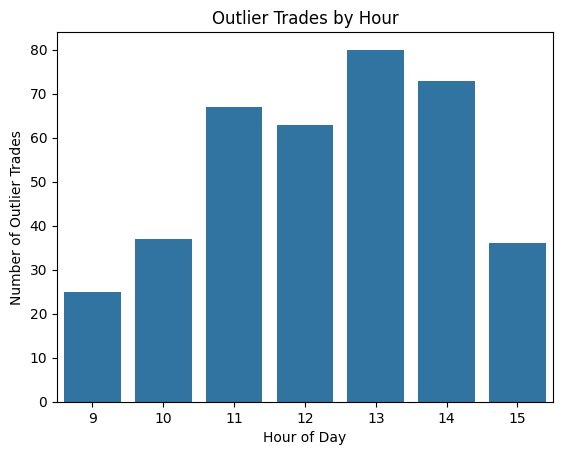

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="hour", data=outliers)
plt.title("Outlier Trades by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Outlier Trades")

plt.savefig("../plots/outlier_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()


In [66]:
import pandas as pd

ml_summary = pd.DataFrame({
    "Model": ["Baseline", "XGBoost Filtered", "LSTM Filtered"],
    "Total_Return": [
        baseline_return,
        xgb_return,
        lstm_return
    ]
})

ml_summary.to_csv("../results/ml_return_comparison.csv", index=False)


In [68]:
model.save("../models/lstm_trade_filter")


2026-01-17 14:16:42.312925: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-01-17 14:16:42.314226: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-01-17 14:16:42.316159: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

INFO:tensorflow:Assets written to: ../models/lstm_trade_filter/assets


INFO:tensorflow:Assets written to: ../models/lstm_trade_filter/assets
